# Comparative reporting

Step-by-step notebook for comparing flat evaluation runs with `soda_mmqc.reporting`.

We build one comparison view at a time. We load **both models** up front; later steps will compare models as well as prompts.

Views so far: **per-run dashboard** (`build_dashboard`), **Structure (Layer S)**, **Applicability (Layer 1)**, and **Matching (Layer 2)** — each with prompt/model multiplots and culprit tables.

| | |
|--|--|
| **Check** | `micrograph-scale-bar` |
| **Models** | `gpt-5-mini-2025-08-07`, `gpt-5` |
| **Prompts** | `prompt.1`, `prompt.2`, `prompt.3` |

Run with the project venv (`uv sync`) from the repo root.

## Setup

In [1]:
from __future__ import annotations

import pandas as pd

from soda_mmqc.reporting import (
    build_dashboard,
    load_flat_runs,
    plot_comparison_layer1,
    plot_comparison_layer2_binary,
    plot_comparison_layer2_graded,
    plot_comparison_layer_s,
    show_instance_context,
    show_layer1_errors,
    show_layer2_errors,
    show_table,
    summarize_runs,
)
from soda_mmqc.reporting.styles import (
    LAYER1_TITLE,
    LAYER2_BINARY_TITLE,
    LAYER2_GRADED_TITLE,
    LAYER_S_TITLE,
)

CHECKLIST = "fig-checklist"
CHECK = "micrograph-scale-bar"
GPT_5_MODEL = "gpt-5"
GPT_5_MINI_MODEL = "gpt-5-mini-2025-08-07"
MODELS = [GPT_5_MINI_MODEL, GPT_5_MODEL]
PROMPTS = ["prompt.1", "prompt.2", "prompt.3"]

LAYER_S_FIG_HEIGHT = 300
LAYER_S_FIG_WIDTH = 500
LAYER1_FIG_HEIGHT = 700
LAYER1_FIG_WIDTH = 1200
LAYER2_FIG_HEIGHT = 500
LAYER2_FIG_WIDTH = 1200
DASHBOARD_FIG_HEIGHT = 300
DASHBOARD_FIG_WIDTH = 1200


2026-06-15 16:41:52 - INFO - ✅ OpenAI API provider configured


### Load runs and summarize

Load all `(model, prompt)` pairs we will need for prompt and model contrasts. One `RunSummary` per pair. Layer S counts live in `by_list_row_counts` (keyed by predictive list, usually `outputs`).

In [2]:
runs = load_flat_runs(
    CHECKLIST,
    CHECK,
    models=MODELS,
    prompts=PROMPTS,
)
summaries = summarize_runs(runs)

pd.DataFrame(
    [
        {
            "model": run.model,
            "prompt": run.prompt,
            "records": len(run.records),
            "by_list_keys": ", ".join(
                summaries[run.model, run.prompt].by_list_keys
            ),
        }
        for run in runs
    ]
)

,model,prompt,records,by_list_keys
0,gpt-5-mini-2025-08-07,prompt.1,14,outputs
1,gpt-5-mini-2025-08-07,prompt.2,14,outputs
2,gpt-5-mini-2025-08-07,prompt.3,14,outputs
3,gpt-5,prompt.1,14,outputs
4,gpt-5,prompt.2,14,outputs
5,gpt-5,prompt.3,14,outputs


## Per-run dashboard (`build_dashboard`)

Single four-panel Plotly figure for one `(MODEL, PROMPT)` pair: Layer S counts, then Layer 1 / Layer 2 binary / Layer 2 graded stacked bars by field.

Use this as a quick snapshot before the comparison grids below. It does **not** overlay prompts or models — see whether that one-glance view is still worth keeping alongside the step-by-step sections.

In [3]:
(
    build_dashboard(summaries[GPT_5_MODEL, PROMPTS[0]])
    .update_layout(
        width=DASHBOARD_FIG_WIDTH,
        height=500,
        autosize=True,
        margin=dict(l=40, r=20, t=50, b=40),
    )
)

## Structural reporting

Reporting whether the lists of objects, ie. the panels, are correct, missing or spurious on this check.

In [4]:
fig_layer_s = plot_comparison_layer_s(
    summaries,
    compare="prompt",
    model=GPT_5_MODEL,
)
if fig_layer_s is None:
    print(f"No {LAYER_S_TITLE} data for model={MODEL}")
else:
    fig_layer_s.update_layout(
        height=LAYER_S_FIG_HEIGHT,
        width=LAYER_S_FIG_WIDTH,
        autosize=True,
        margin=dict(l=40, r=20, t=50, b=40),
    )
    fig_layer_s.show()

## Applicability reporting (Layer 1)

Per leaf field: stacked applicability outcomes. One subplot per field; prompts or models on the x-axis within each panel.

### Comparing prompts

Subplot grid for `MODEL` (default `gpt-5`): three stacked bars per panel (one per prompt, distinguished by **opacity**).

In [5]:
fig_layer1_prompt = plot_comparison_layer1(
    summaries,
    compare="prompt",
    model=GPT_5_MODEL,
)
fig_layer1_prompt.update_layout(
    height=LAYER1_FIG_HEIGHT,
    width=LAYER1_FIG_WIDTH,
    autosize=True,
)
fig_layer1_prompt.show()

### Comparing models

Same layout for `PROMPT` (default `prompt.2`). Models on the x-axis; distinguished by **bar hatching**.

In [6]:
fig_layer1_model = plot_comparison_layer1(
    summaries,
    compare="model",
    prompt=PROMPTS[0],
)
fig_layer1_model.update_layout(
    height=LAYER1_FIG_HEIGHT,
    width=LAYER1_FIG_WIDTH,
    autosize=True,
)
fig_layer1_model.show()

### Applicability culprits

Instance table for one `(MODEL, PROMPT)` pair. Pre-filtered to `CULPRIT_LAYER1`; adjust filters in the table footer.

In [7]:
summary_selected = summaries[GPT_5_MODEL, PROMPTS[2]]

show_layer1_errors(
    summary_selected,
    layer1="spurious_applicable",
    caption=(
        f"Layer 1 culprits — {CHECK} / {GPT_5_MODEL} / {PROMPTS[2]} "
        f"(initial filter: spurious_applicable)"
    ),
)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


## Matching reporting (Layer 2)

This check mixes **binary** fields (e.g. `micrograph`, `scale_bar_*`) and **graded** string fields (e.g. `from_the_caption`). One subplot per field in each chart.

### Matching-binary — comparing prompts

Subplot grid for `MODEL`: stacked TP/TN/FP/FN; prompts distinguished by **opacity**.

In [8]:
fig_layer2_binary_prompt = plot_comparison_layer2_binary(
    summaries,
    compare="prompt",
    model=GPT_5_MODEL,
)
fig_layer2_binary_prompt.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_binary_prompt.show()

### Matching-binary — comparing models

Same layout for `PROMPT`; models distinguished by **bar hatching**.

In [9]:
fig_layer2_binary_model = plot_comparison_layer2_binary(
    summaries,
    compare="model",
    prompt=PROMPTS[2],
)
fig_layer2_binary_model.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_binary_model.show()

### Matching-graded — comparing prompts

Graded string fields only (`match` / `mismatch` stacks).

In [10]:
fig_layer2_graded_prompt = plot_comparison_layer2_graded(
    summaries,
    compare="prompt",
    model=GPT_5_MODEL,
)
fig_layer2_graded_prompt.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_graded_prompt.show()

### Matching-graded — comparing models

In [11]:
fig_layer2_graded_model = plot_comparison_layer2_graded(
    summaries,
    compare="model",
    prompt=PROMPTS[2],
)
fig_layer2_graded_model.update_layout(
    height=LAYER2_FIG_HEIGHT,
    width=LAYER2_FIG_WIDTH,
    autosize=True,
)
fig_layer2_graded_model.show()

### Matching culprits

Instance-level layer-1 outliers and layer-2 errors for one `(MODEL, PROMPT)` pair.

In [12]:
show_layer2_errors(
    summaries[GPT_5_MODEL, PROMPTS[2]],
    caption=f"Layer 2 culprits — {CHECK} / {GPT_5_MODEL} / {PROMPTS[2]}",
)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


## Instance drill-down

Pick a row from a culprit table (`source`, `path`, `leaf_property`) — or set only `source` to see the full model output for that example call (caption, figure, gold vs pred JSON).

**Example context** — `fig-checklist` / `micrograph-scale-bar` / `gpt-5` / `prompt.3`  
`source=10.1038_s44318-026-00715-1/content/3` · `steps=['outputs', 7, 'micrograph']`

**Caption**  
Figure 3: PacL2 clustering and dynamics.(A, B) Representative 3D super-resolution reconstructions of PacL2-mEos or CtpG-mEos in M. smegmatis cells using 3D PALM. From left to right: localizations, density map, 3D localizations, and cluster segmentation using the PoCA software. Quantification of (C) the number of PacL2 or CtpG clusters per cell, (D) cluster sizes, and (E) proportion of clustered molecules per cell. Results are presented as means ( ± SEM) from individual cells (C, E) or clusters (D), represented by gray dots. (F) Representative super-resolution reconstructions of PacL2-mEos protein acquired by sptPALM. From left to right: localizations, trajectories with lengths > 6 time points, overlay between slow (cyan) and fast (magenta) molecules, threshold = 0.03 µm2.s−1. (G) Top: Histogram of diffusion coefficients computed from 19 cells. Bottom: mean square displacement of the molecules computed from the trajectories of the cell in (F). (H) Trajectories and kymograph analysis along the long axis of the cell, color-coded with their diffusion coefficients, examples of trajectories showing immobilized (1 and 4), freely diffusive (2, 3, and 6), and highly mobile molecules (5 and 7). Asterisks above the means indicate statistically significant differences compared to the reference condition (PacL2) (*P < 0.05; ****P < 0.0001), calculated using an unpaired t-test. Exact p values and replicate numbers presented in this figure are reported in Table EV6. PacL2mEos: PacL2-mEos fusion; CtpGmEos: CtpG-mEos fusion.

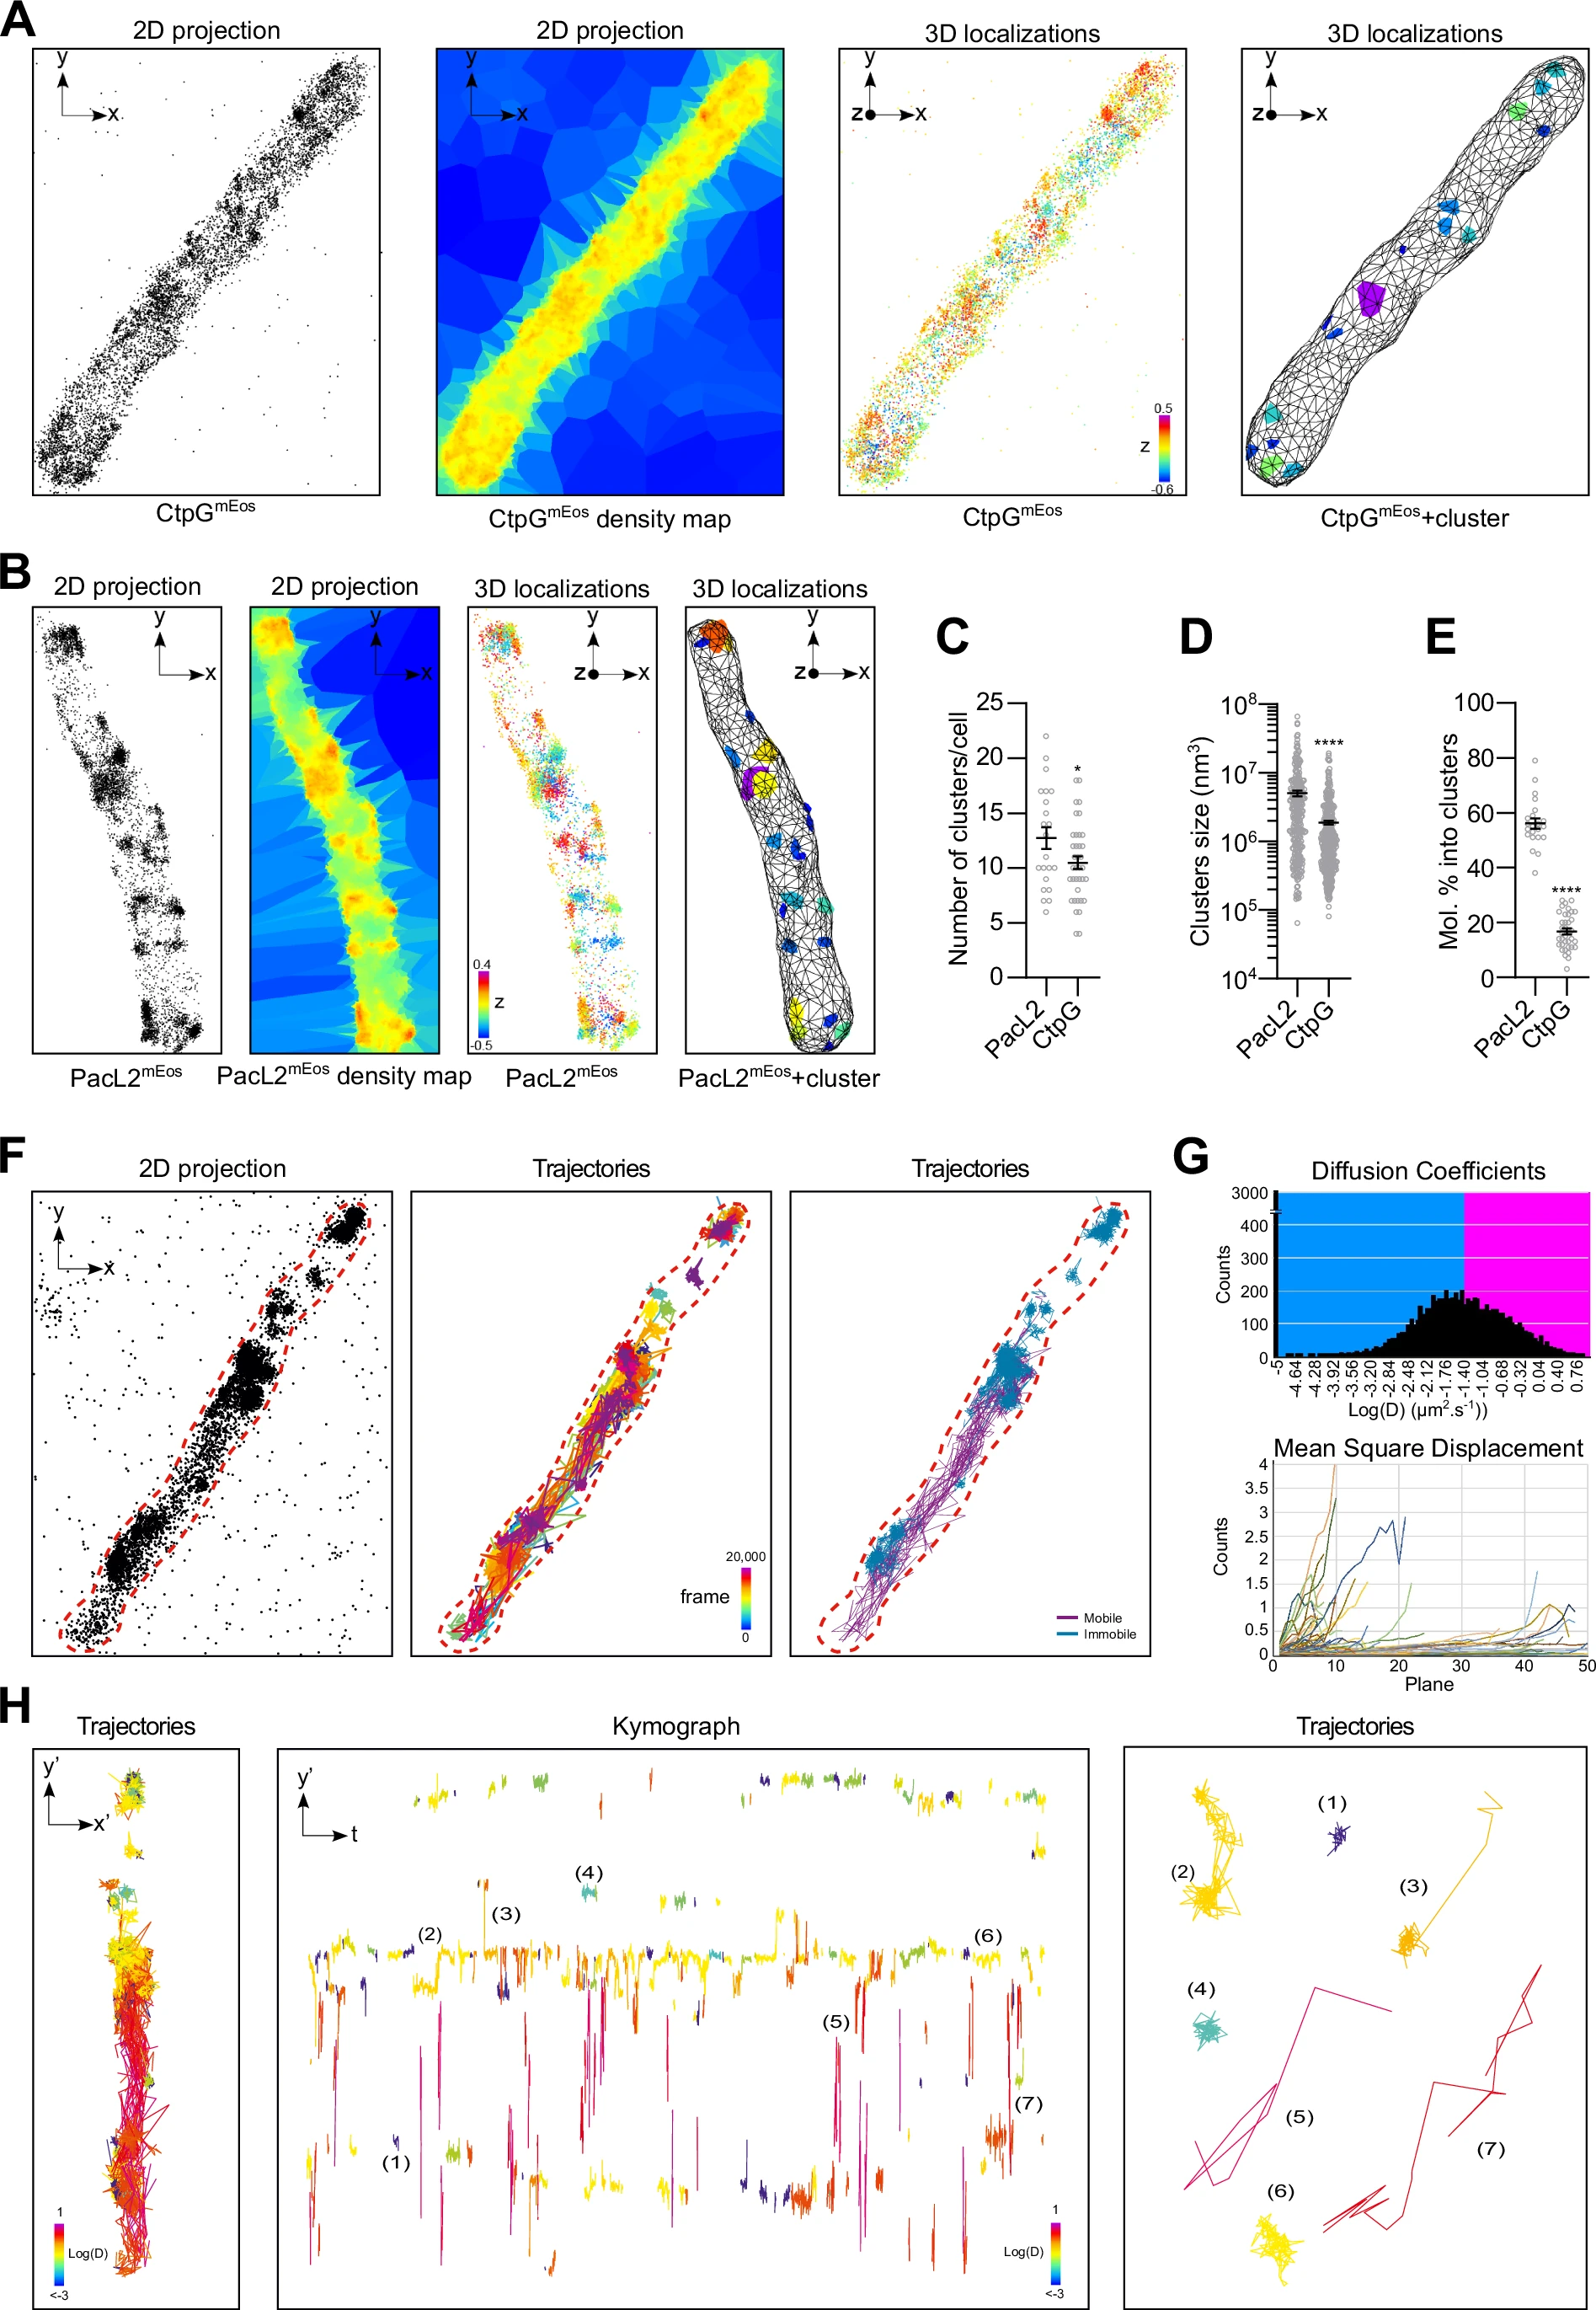

**Panel row (gold vs pred)**

,gold row,pred row
0,"{\n ""panel_label"": ""H"",\n ""micrograph"": ""no""...","{\n ""panel_label"": ""H"",\n ""micrograph"": ""yes..."


**`micrograph` (gold vs pred)**

,gold,pred
0,'no','yes'


**Prompt**

```
# Micrograph-scale-bar

## Summary
You are a scientific technical editor specialized in the quality control of scientific figures and data presentation. Your task is to analyze a scientific figure to check for the presence of a scale bar on micrographs and make sure they are properly defined either in the image itsself or in the caption.

Proceed step-by-step and establish a systematical strategy to be very accurate and avoid mistakes.

## 1. Identify all figure panels
Understand the figure image and see where there are figure sub-part or "panels". Each panel depicts an experiment either with a plot, a micrograph, some other kinds of images, a scheme. Panels are typically labeled with consecutive letters (for example: A, B, C, ... or (a), (b), (c)). The first panel is usually on the top left. The last panel tends to be on the bottom right. Sometimes the layout is however a bit messy. Sometimes a panel can include several images. For example, a panel can include both a microscopy image and a plot. For each panel, locate the corresponding description in the figure caption.

## 2. Identify microscopy images and check for scale bars
For each panel in the figure:
- Determine whether the panel image is a micrograph, a picture of a microscopic sample, microscopy images. 
- If and only if it is a micrograph or microscopic image, check whether there is a scale bar in the image. A scale bar is a visual reference element added to scientific micrographs (microscopic images) that indicates the actual size of the objects being depicted. It typically appears as a line or bar of defined length. 

## 3. Identify if scale bar is defined in the image itsself or in the figure caption
In some cases the defined length of the scale bar is written in the image itsself and displayed as label such as "10 μm" or "500 nm" or it is defined only in the figure caption. For each microscopy image identified in step 2 check:
- If the scale bar is defined in the image itsself. This would be indicated with a number and a unit next to the scale bar.  
- If the scale bar is defined in the figure caption. 

## 4. Extract scale bar information
- If the scale bar is defined in the image itsself, extract the scale bar information from the image. This encompasses the number and the unit, for example "500 nm". 
- If the scale bar is described in the text, extract the exact text from the caption that defines the scale bar.
*IMPORTANT:* When extracting the text from the caption, *ONLY* include the specific text that describes the scale bar. Do NOT include general descriptions of the figure or panel content.

Provide your analysis in the following JSON format for EACH and EVERY panel:

{
    "outputs": [
        {
            "panel_label": "A",
            "micrograph": "yes",
            "scale_bar_on_image": "yes",
            "scale_bar_defined_in_caption": "yes",
            "from_the_caption": "Scale bar 10 μm",
            "scale_bar_defined_in_image": "no",
            "from_the_image": ""
        },
        {
            "panel_label": "B",
            "micrograph": "yes",
            "scale_bar_on_image": "yes",
            "scale_bar_defined_in_caption": "no",
            "from_the_caption": "",
            "scale_bar_defined_in_image": "yes",
            "from_the_image": "100 μm"
        },
        {
            "panel_label": "C",
            "micrograph": "no",
            "scale_bar_on_image": "",
            "scale_bar_defined_in_caption": "",
            "from_the_caption": "",
            "scale_bar_defined_in_image": "",
            "from_the_image": ""
        },
        {
            "panel_label": "D",
            "micrograph": "yes",
            "scale_bar_on_image": "yes",
            "scale_bar_defined_in_caption": "no",
            "from_the_caption": "",
            "scale_bar_defined_in_image": "yes",
            "from_the_image": "500 nm"
        },


    ]
}

Be thorough and precise in your analysis. Include all panels visible in the figure, even if they don't contain micrographs or microscopy images.
```

In [13]:
# Selectors — copy from a culprit table row, or set only SOURCE for the full example
DRILL_SOURCE = "10.1038_s44318-026-00715-1/content/3"
DRILL_OBJECT_PATH = "outputs[7]"  # panel row within this source's outputs[]
DRILL_LEAF = "micrograph"

show_instance_context(
    summaries[GPT_5_MODEL, PROMPTS[2]],
    source=DRILL_SOURCE,
    object_path=DRILL_OBJECT_PATH,
    leaf=DRILL_LEAF,
)